<a href="https://colab.research.google.com/github/gmauricio-toledo/NLP-LCC/blob/main/Notebooks/10-SVD_EspaciosLatentes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h1>LSA, Espacios Latentes y Sistemas de recomendación</h1>

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [29]:
FILE_PATH    = "calificaciones_peliculas.xlsx"
SHEET        = "Calificaciones"
MIN_RATINGS  = 2   # mínimo de calificaciones para incluir una fila/columna

In [30]:
#@title Funciones procesamiento

def load_matrix(file_path: str, sheet: str) -> tuple[pd.DataFrame, list, list]:
    """
    Lee el Excel y devuelve un DataFrame con NaN donde no hay calificación.
    * Filas: alumnos
    * Columnas: películas
    """
    wb_df = pd.read_excel(file_path, sheet_name=sheet, header=None)

    # Fila 2 (índice 1): nombres de películas (columnas B en adelante)
    movie_names = wb_df.iloc[1, 1:].tolist()

    # Fila 4 en adelante (índice 3+): datos de alumnos
    data_rows = wb_df.iloc[3:, :]
    student_names = data_rows.iloc[:, 0].tolist()
    ratings_raw   = data_rows.iloc[:, 1:].reset_index(drop=True)
    ratings_raw.columns = movie_names
    ratings_raw.index   = student_names

    # Convertir a numérico; todo lo que no sea -2..2 se vuelve NaN
    R = ratings_raw.apply(pd.to_numeric, errors='coerce')
    R = R.where(R.isin([-2, -1, 0, 1, 2]))

    return R, student_names, movie_names


def clean_matrix(R: pd.DataFrame,
                 min_ratings: int = MIN_RATINGS) -> pd.DataFrame:
    """
    Elimina filas y columnas con menos de `min_ratings` valores observados.
    Itera hasta estabilizar (un alumno con pocas calificaciones puede dejar
    películas vacías, y viceversa).
    """
    prev_shape = None
    while R.shape != prev_shape:
        prev_shape = R.shape
        R = R.loc[R.notna().sum(axis=1) >= min_ratings]  # alumnos con suficientes ratings
        R = R.loc[:, R.notna().sum(axis=0) >= min_ratings]  # películas con suficientes ratings
    return R


def mean_center(R: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """
    Mean-centering por fila (resta la media de cada alumno).
    Imputa los NaN resultantes con 0 (= "sin opinión").
    Devuelve la matriz centrada y las medias por alumno.
    """
    user_means = R.mean(axis=1)
    R_centered = R.sub(user_means, axis=0)
    R_imputed  = R_centered.fillna(0)
    return R_imputed, user_means


Cargamos la matriz de calificaciones

In [32]:
R_raw, students, movies = load_matrix(FILE_PATH, SHEET)

print(f"Matriz cargada:  {R_raw.shape[0]} alumnos × {R_raw.shape[1]} películas")
print(f"Celdas con valor: {R_raw.notna().sum().sum()} / {R_raw.size} "
      f"({round(R_raw.notna().sum().sum()/R_raw.size*100,1)}% densidad)")

Matriz cargada:  20 alumnos × 21 películas
Celdas con valor: 176 / 420 (41.9% densidad)


Limpiamos la matriz: imputamos, reescalamos y filtramos filas sin suficientes calificaciones

In [36]:
R_clean = clean_matrix(R_raw, min_ratings=MIN_RATINGS)

print(f"\nTras limpieza (>={MIN_RATINGS} calificaciones): "
      f"{R_clean.shape[0]} alumnos × {R_clean.shape[1]} películas")
print(f"Densidad final: {R_clean.notna().sum().sum()/R_clean.size*100:.1f}%")

# Alumnos/películas que quedaron fuera
dropped_students = set(R_raw.index) - set(R_clean.index)
dropped_movies   = set(R_raw.columns) - set(R_clean.columns)
if dropped_students:
    print(f"\nAlumnos excluidos por pocas calificaciones:\n{dropped_students}")
if dropped_movies:
    print(f"Películas excluidas por pocas calificaciones:\n{dropped_movies}")

R_imputed, user_means = mean_center(R_clean)

print(f"\nMatriz para Truncated SVD: {R_imputed.shape}")
print("Primeras 3 filas:")
display(R_imputed.iloc[:3, :3].round(2))


Tras limpieza (>=2 calificaciones): 10 alumnos × 21 películas
Densidad final: 83.8%

Alumnos excluidos por pocas calificaciones:
{'Gonzalez Borquez Francisco Mario', 'Caro Perez Horacio', 'Castro Cordova Joaquin Alfredo', 'Chenoweth Galaz Ana Laura', 'Antunez Lopez Denisse Gabriela', 'Guerrero Hernandez Jorge Alberto', 'Cruz Duarte Miguel Angel', 'Gortarez Blanco Manuel Eduardo', 'Borquez Guerrero Angel Fernando', 'Dennis Vargas Mirka Galileo'}

Matriz para Truncated SVD: (10, 21)
Primeras 3 filas:


,Cars (2006),Toy Story 3 (2010),The Incredibles (2004)
Heredia Nogales Manuel Alejandro,2.58,-1.42,1.58
Jacome Toro Luis Enrique,0.95,-0.05,1.95
Juarez Cabrera Francisco Alejandro,-0.22,1.78,0.78


## Singular Value Decomposition

Recordar que la forma es `estudiantes x películas`

In [20]:
R_imputed.shape

(10, 21)

In [37]:
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

K = 2  # componentes latentes para explorar

svd = TruncatedSVD(n_components=K, random_state=42)
U = svd.fit_transform(R_imputed.values)          # proyección de alumnos (n × K)
Vt = svd.components_                              # proyección de películas (K × m)
V  = Vt.T                                         # (m × K)

print(f"\nVarianza explicada por {K} componentes: "
      f"{svd.explained_variance_ratio_.sum()*100:.1f}%")
print(f"  Comp 1: {svd.explained_variance_ratio_[0]*100:.1f}%")
print(f"  Comp 2: {svd.explained_variance_ratio_[1]*100:.1f}%")


Varianza explicada por 2 componentes: 37.8%
  Comp 1: 19.9%
  Comp 2: 17.9%


In [38]:
components = svd.components_.T
print(f"Matriz componentes-peliculas: {components.shape}")

Matriz componentes-peliculas: (21, 2)


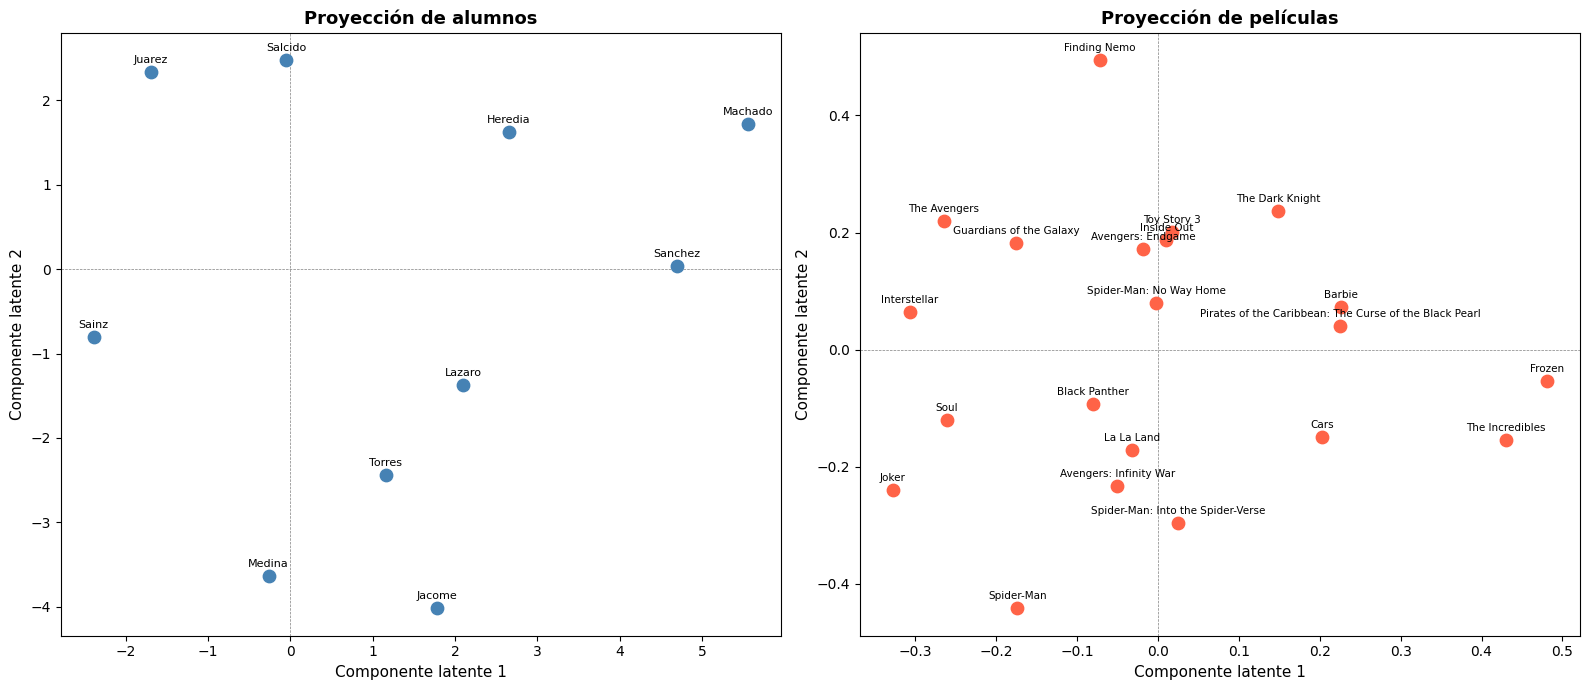

In [39]:
student_names_clean = list(R_clean.index)
movie_names_clean   = list(R_clean.columns)

# === Plot alumnos ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax = axes[0]
ax.scatter(U[:, 0], U[:, 1], s=80, color='steelblue', zorder=3)
for i, name in enumerate(student_names_clean):
    label = name.split()[0] if name else str(i) # Mostrar solo apellido
    ax.annotate(label, (U[i, 0], U[i, 1]),
                fontsize=8, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Componente latente 1', fontsize=11)
ax.set_ylabel('Componente latente 2', fontsize=11)
ax.set_title('Proyección de alumnos', fontsize=13, fontweight='bold')

# === Plot películas ===
ax = axes[1]
ax.scatter(V[:, 0], V[:, 1], s=80, color='tomato', zorder=3)
for i, name in enumerate(movie_names_clean):
    short = name.split('(')[0].strip() # Título corto (sin año)
    ax.annotate(short, (V[i, 0], V[i, 1]),
                fontsize=7.5, ha='center', va='bottom',
                xytext=(0, 5), textcoords='offset points')
ax.axhline(0, color='gray', lw=0.5, ls='--')
ax.axvline(0, color='gray', lw=0.5, ls='--')
ax.set_xlabel('Componente latente 1', fontsize=11)
ax.set_ylabel('Componente latente 2', fontsize=11)
ax.set_title('Proyección de películas', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('proyecciones_svd.png', dpi=150, bbox_inches='tight')
plt.show()

## Máxima afinidad

In [40]:
from numpy import argmax

X_transformed = U.copy() # Matriz estudiantes x latentes
print(X_transformed.shape)

x_arg = argmax(X_transformed, axis=1) # Componente con máxima afinidad
print(x_arg.shape)
x_arg

(10, 2)
(10,)


array([0, 0, 1, 0, 0, 0, 1, 1, 0, 0])

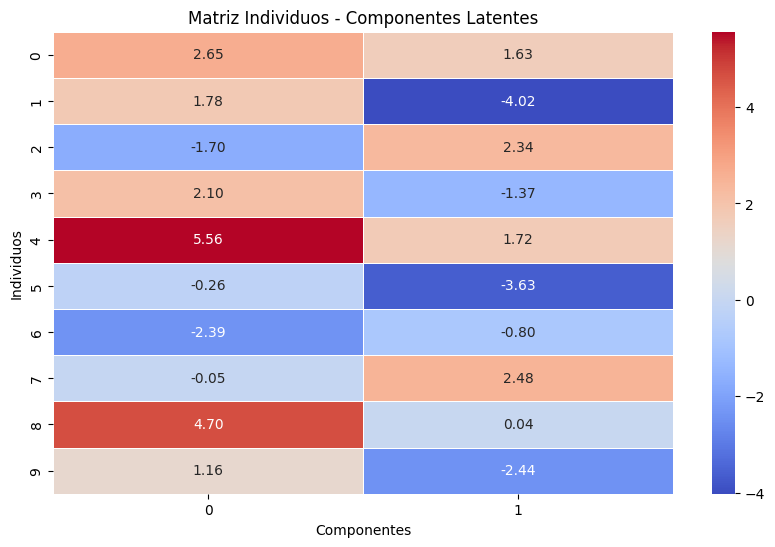

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(X_transformed, cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz Individuos - Componentes Latentes')
plt.xlabel('Componentes')
plt.ylabel('Individuos')
plt.show()

In [41]:
svd.components_.transpose() # Matriz películas x latentes
print(svd.components_.transpose().shape)

components_arg = argmax(svd.components_.transpose(), axis=1) # Componente con máxima afinidad
components_arg

(21, 2)


array([0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0])

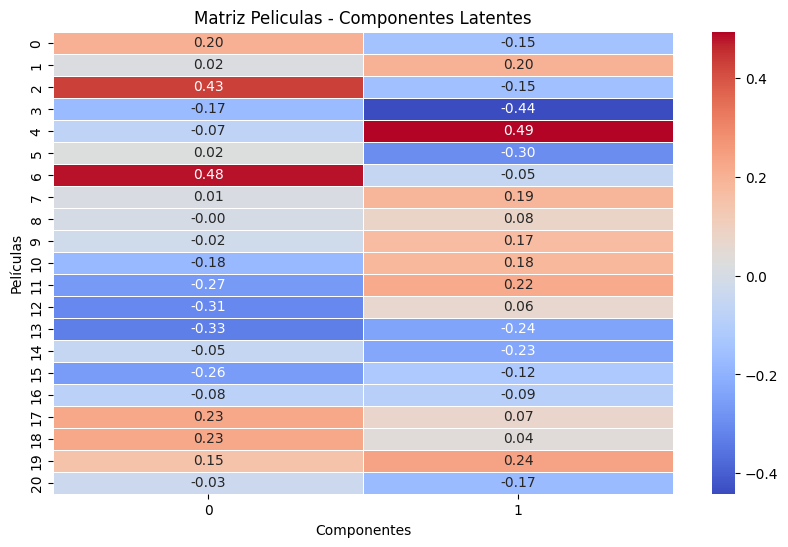

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(svd.components_.transpose(), cmap='coolwarm', annot=True, fmt='.2f', linewidths=0.5)
plt.title('Matriz Peliculas - Componentes Latentes')
plt.xlabel('Componentes')
plt.ylabel('Películas')
plt.show()

## Peliculas agrupadas por grupos

In [23]:
for j in range(X_transformed.shape[1]):
    movie_idxs = np.where(components_arg==j)[0]
    print(f"Grupo {j+1}:")
    for idx in movie_idxs:
        print(f"\t{movies[idx]}")

Grupo 1:
	Cars (2006)
	The Incredibles (2004)
	Spider-Man (2002)
	Spider-Man: Into the Spider-Verse (2018)
	Frozen (2013)
	Avengers: Infinity War (2018)
	Black Panther (2018)
	Barbie (2023)
	Pirates of the Caribbean: The Curse of the Black Pearl (2003)
	La La Land (2016)
Grupo 2:
	Toy Story 3 (2010)
	Finding Nemo (2003)
	Inside Out (2015)
	Spider-Man: No Way Home (2021)
	Avengers: Endgame (2019)
	Guardians of the Galaxy (2014)
	The Avengers (2012)
	Interstellar (2014)
	Joker (2019)
	Soul (2020)
	The Dark Knight (2008)


## Cercania en el espacio de proyecciones: Sistemas de recomendación

In [25]:
individuos_embeddings = X_transformed.copy()
peliculas_embeddings = svd.components_.transpose().copy()

In [26]:
from sklearn.neighbors import NearestNeighbors

nn = NearestNeighbors(n_neighbors=5, metric='cosine')
nn.fit(individuos_embeddings)

for j,x in enumerate(student_names_clean):
    distances, indices = nn.kneighbors([individuos_embeddings[j]])
    idx = indices[0][1]
    print(f"Más similar a {x}: {student_names_clean[idx]}")

Más similar a Heredia Nogales Manuel Alejandro: Machado Felix Flor Maria
Más similar a Jacome Toro Luis Enrique: Torres Flores Alan David
Más similar a Juarez Cabrera Francisco Alejandro: Salcido Valenzuela Georgina
Más similar a Lazaro Silva Joan Antonio: Torres Flores Alan David
Más similar a Machado Felix Flor Maria: Heredia Nogales Manuel Alejandro
Más similar a Medina Lugo Fausto Misael: Jacome Toro Luis Enrique
Más similar a Sainz Peñuñuri Luis Mario: Medina Lugo Fausto Misael
Más similar a Salcido Valenzuela Georgina: Juarez Cabrera Francisco Alejandro
Más similar a Sanchez Bermudez Braulio Alessandro: Machado Felix Flor Maria
Más similar a Torres Flores Alan David: Jacome Toro Luis Enrique


In [27]:
nn = NearestNeighbors(n_neighbors=5, metric='cosine')
nn.fit(peliculas_embeddings)

for j,x in enumerate(movies):
    distances, indices = nn.kneighbors([peliculas_embeddings[j]])
    idx = indices[0][1]
    print(f"Más similar a {x}: {movies[idx]}")

Más similar a Cars (2006): The Incredibles (2004)
Más similar a Toy Story 3 (2010): Inside Out (2015)
Más similar a The Incredibles (2004): Frozen (2013)
Más similar a Spider-Man (2002): Avengers: Infinity War (2018)
Más similar a Finding Nemo (2003): Avengers: Endgame (2019)
Más similar a Spider-Man: Into the Spider-Verse (2018): La La Land (2016)
Más similar a Frozen (2013): The Incredibles (2004)
Más similar a Inside Out (2015): Toy Story 3 (2010)
Más similar a Spider-Man: No Way Home (2021): Avengers: Endgame (2019)
Más similar a Avengers: Endgame (2019): Finding Nemo (2003)
Más similar a Guardians of the Galaxy (2014): The Avengers (2012)
Más similar a The Avengers (2012): Guardians of the Galaxy (2014)
Más similar a Interstellar (2014): The Avengers (2012)
Más similar a Joker (2019): Soul (2020)
Más similar a Avengers: Infinity War (2018): La La Land (2016)
Más similar a Soul (2020): Joker (2019)
Más similar a Black Panther (2018): Joker (2019)
Más similar a Barbie (2023): Pirate